# CISM Tutorial 03: Analysis From The Serialized CISM Artifact

This notebook starts from the pickle artifact saved at the end of tutorial 02.

It follows the same general analysis direction as the existing `CISM_on_CRC.ipynb` workflow, but starts from the already-prepared CISM state instead of rebuilding the workflow from raw setup.

## What This Notebook Covers

In this notebook we will:

1. load the serialized artifact from tutorial 02
2. recover the selected analysis configuration
3. rebuild the discriminative motif result at the chosen state
4. show motif count vs stringency
5. draw the top 5 motifs ranked by `stringency * count`
6. compare motif-induced pairwise analysis to general pairwise analysis for each disease state
7. export the top-5 motif annotation files and exact-hit wide CSV files for downstream visualization and analysis

In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from cism import (
    DiscriminativeFeatureKey,
    export_top_motif_visualization_inputs,
    rank_motifs_by_stringency_count,
    motif_to_annotation_text,
)
from cism.cism import GetMotifsResult
from cism.helpers import create_weight_matrix_from_motifs, string_base64_pickle
from cism.vis.draw import draw_motif
from pairwise import GraphReader, PairwiseAnalysis


In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "tutorials" else Path.cwd().resolve()
TUTORIAL_RUNTIME_DIR = PROJECT_ROOT / "tutorials" / "runtime"
SERIALIZED_ROOT = TUTORIAL_RUNTIME_DIR / "serialized"
ANALYSIS_OUTPUT_ROOT = TUTORIAL_RUNTIME_DIR / "analysis_outputs"
TOP_MOTIF_EXPORT_ROOT = ANALYSIS_OUTPUT_ROOT / "motif_visualization_inputs"

ANALYSIS_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
TOP_MOTIF_EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Serialized artifact directory: {SERIALIZED_ROOT}")
print(f"Analysis output directory: {ANALYSIS_OUTPUT_ROOT}")
print(f"Top motif export directory: {TOP_MOTIF_EXPORT_ROOT}")


Serialized artifact directory: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/serialized
Analysis output directory: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/analysis_outputs
Top motif export directory: /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/analysis_outputs/motif_visualization_inputs


## Load The Artifact From Tutorial 02

Choose the `.pkl` created in tutorial 02.

Example filename:

- `example_dataset_cism_ready.pkl`

In [3]:
# Replace with the artifact file created in tutorial 02.
artifact_path = SERIALIZED_ROOT / "TNBC_cism_ready.pkl"

with open(artifact_path, "rb") as handle:
    artifact = pickle.load(handle)

artifact.keys()


dict_keys(['cism', 'discriminator', 'best_feature_conf', 'tuning_best_params', 'tuning_best_score', 'tuning_trials_df', 'network_dataset_root_path', 'dataset_folder', 'dataset_name', 'fanmod_path', 'fanmod_exe', 'fanmod_output_root_path', 'fanmod_cache_root_path', 'tissue_state_csv_path', 'tissue_state_to_string', 'tissue_state_mode', 'survival_rate_cutoff', 'common_cells_type', 'labels', 'missing_tissue_state'])

In [4]:
cism = artifact["cism"]
discriminator = artifact["discriminator"]
best_feature_conf = artifact["best_feature_conf"]
network_dataset_root_path = artifact["network_dataset_root_path"]
dataset_folder = artifact["dataset_folder"]
fanmod_output_root_path = artifact["fanmod_output_root_path"]
fanmod_cache_root_path = artifact["fanmod_cache_root_path"]
tissue_state_csv_path = artifact["tissue_state_csv_path"]
tissue_state_to_string = artifact["tissue_state_to_string"]
common_cells_type = artifact["common_cells_type"]
labels = artifact["labels"]

survival_rate_cutoff = artifact.get("survival_rate_cutoff", 1000)


def map_survival_rate_to_class(survival_rate: int):
    if survival_rate < survival_rate_cutoff:
        return "Short-term survival"
    return "Long-term survival"


tissue_state_func = map_survival_rate_to_class if tissue_state_to_string is None else None

dataset_dir = Path(network_dataset_root_path) / dataset_folder

print(f"dataset_dir = {dataset_dir}")
print(f"labels = {labels}")
print(f"best_feature_conf.shared_percentage = {best_feature_conf.shared_percentage}")
print(f"best_feature_conf.max_class_features = {best_feature_conf.max_class_features}")


dataset_dir = /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC
labels = ['Short-term survival', 'Long-term survival']
best_feature_conf.shared_percentage = 0.4404145064107466
best_feature_conf.max_class_features = 30


## Rebuild The Current Discriminative Motif Result

We use the discriminator stored in the artifact and reconstruct the discriminative motif table for the selected classes.

In [5]:
discover_result = discriminator.discover(
    extract_by=DiscriminativeFeatureKey.STRUCTURE_AND_CELL_IDENTITIES,
    classes=labels,
)

discriminative_motifs_df = discover_result.get_discriminative_motifs().copy()
display(discriminative_motifs_df.head())


,Patient,FOV,ID,Freq,Count,Mean_Freq,STD,z_score,p_value,motif,nunique_colors,Disease,Patient_uId,colors_vec,colors_vec_hash,patient_class,patient_count,patient_percentage
3,10,10,7722444,0.025521,1321,0.019244,0.000713,8.8073,0.0,gASVMAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,TNBC,TNBC10,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0]",-3729389300718233172,Long-term survival,4,0.133333
11,10,10,26596812,0.007419,384,0.003564,0.000305,12.6520,0.0,gASVMQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,TNBC,TNBC10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]",-4991885778241402576,Long-term survival,4,0.133333
61,10,10,5592396,0.000966,50,0.000578,0.000114,3.4013,0.0,gASVMAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,TNBC,TNBC10,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]",-774791192153669712,Long-term survival,9,0.300000
93,10,10,6048076,0.000657,34,0.000201,0.000075,6.0848,0.0,gASVLQEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,TNBC,TNBC10,"[0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]",1304415446218764995,Long-term survival,12,0.400000
109,10,10,18199980,0.000502,26,0.000055,0.000055,8.1547,0.0,gASVMAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,2,TNBC,TNBC10,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]",-1039844095083563261,Long-term survival,6,0.200000


## Motif Count Vs Stringency Scatter Plot

We aggregate each motif by:

- `stringency = max(patient_percentage)`
- `total_count = sum(Count)`

This gives a compact view of motif recurrence versus discrimination stringency.

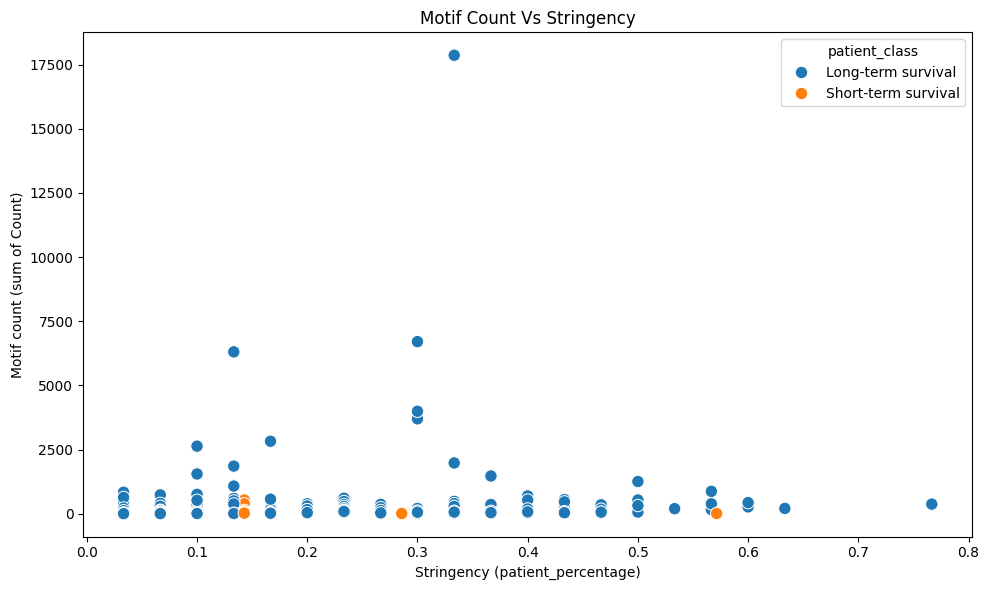

,ID,stringency,total_count,patient_class
1440,6077900,0.766667,373,Long-term survival
1103,3955884,0.633333,204,Long-term survival
1402,6061228,0.600000,431,Long-term survival
1104,3955948,0.600000,265,Long-term survival
1593,8202636,0.571429,7,Short-term survival
1391,6052972,0.566667,870,Long-term survival
1434,6077612,0.566667,385,Long-term survival
1112,3964076,0.566667,157,Long-term survival
1452,6094060,0.533333,196,Long-term survival
1403,6061356,0.533333,188,Long-term survival


In [6]:
motif_count_vs_stringency = (
    discriminative_motifs_df.groupby("ID", observed=True)
    .agg(
        stringency=("patient_percentage", "max"),
        total_count=("Count", "sum"),
        patient_class=("patient_class", lambda values: values.mode().iloc[0]),
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=motif_count_vs_stringency,
    x="stringency",
    y="total_count",
    hue="patient_class",
    s=80,
)
plt.xlabel("Stringency (patient_percentage)")
plt.ylabel("Motif count (sum of Count)")
plt.title("Motif Count Vs Stringency")
plt.tight_layout()
plt.show()

display(motif_count_vs_stringency.sort_values(["stringency", "total_count"], ascending=False).head(20))


## Top 5 Motifs By `Stringency * Count`

We now rank motifs by the combined score:

```text
score = stringency * total_count
```

This gives the 5 motifs we will draw and export.

In [7]:
top5_motifs_df = rank_motifs_by_stringency_count(discover_result=discover_result, top_k=5)
display(top5_motifs_df)


,ID,stringency,total_count,motif,patient_class,score
0,531468,0.333333,17863,gASVKgEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,Long-term survival,5954.333333
1,1837132,0.300000,6704,gASVLAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,Long-term survival,2011.200000
2,1842188,0.300000,3991,gASVSAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,Long-term survival,1197.300000
3,1332300,0.300000,3697,gASVLAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,Long-term survival,1109.100000
4,7722444,0.133333,6305,gASVMAEAAAAAAACMGG5ldHdvcmt4LmNsYXNzZXMuZGlncm...,Long-term survival,840.666667


In [8]:
def load_motif_graph(motif_value):
    if isinstance(motif_value, str):
        return string_base64_pickle(motif_value)
    return motif_value


Motif ID: 531468
Class: Long-term survival
Stringency: 0.3333
Total count: 17863
Score = stringency * count: 5954.3333
A.type = B cells
B.type = B cells
C.type = B cells
A -> C
B -> C



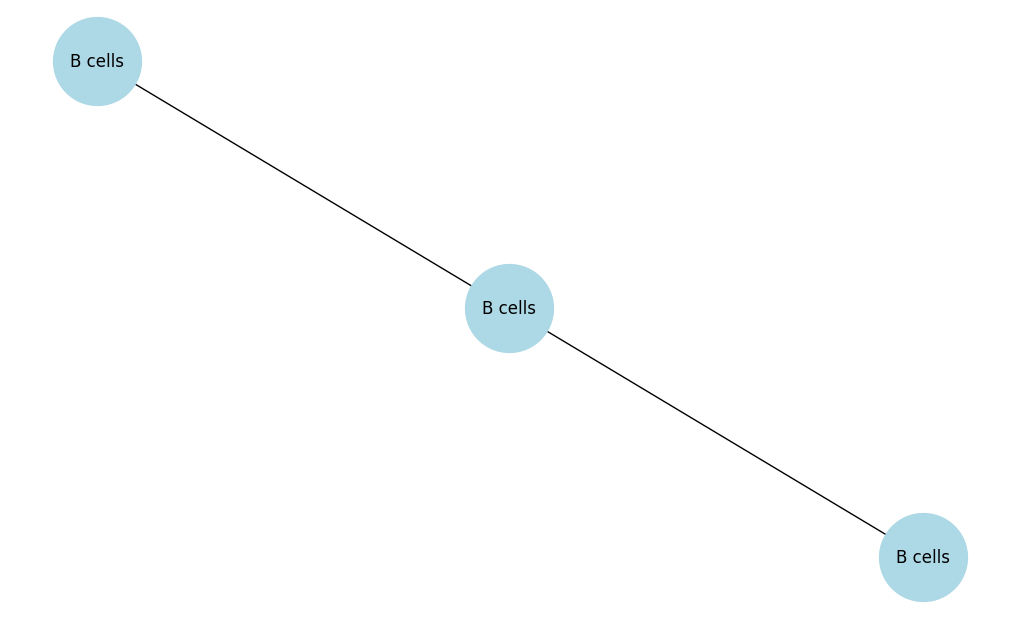

Motif ID: 1837132
Class: Long-term survival
Stringency: 0.3000
Total count: 6704
Score = stringency * count: 2011.2000
A.type = B cells
B.type = B cells
C.type = CD4 t cells
A -> B
A -> C



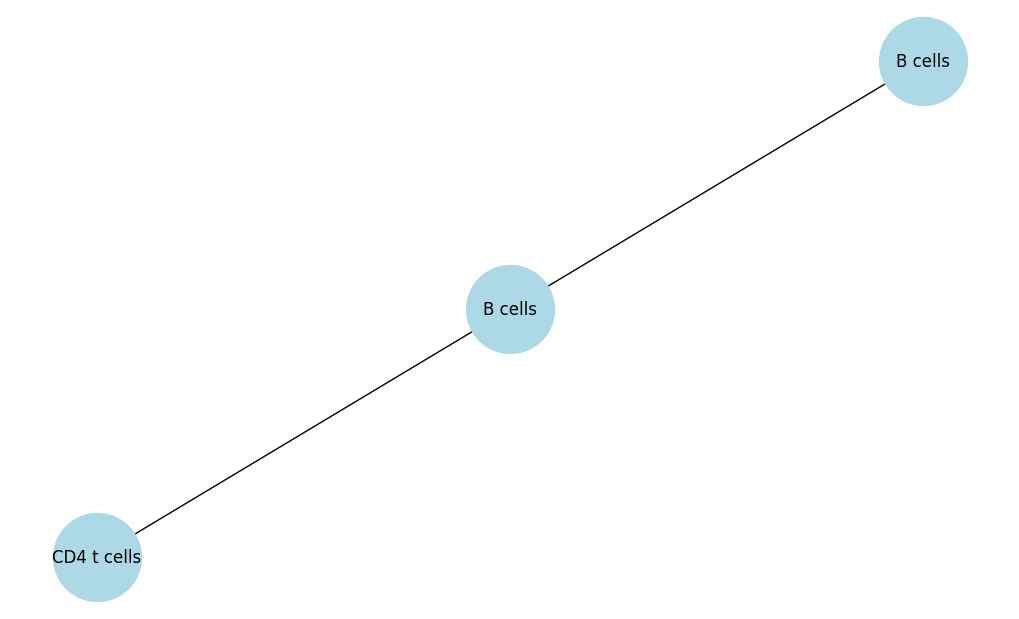

Motif ID: 1842188
Class: Long-term survival
Stringency: 0.3000
Total count: 3991
Score = stringency * count: 1197.3000
A.type = B cells
B.type = B cells
C.type = B cells
A -> B
A -> C
B -> C



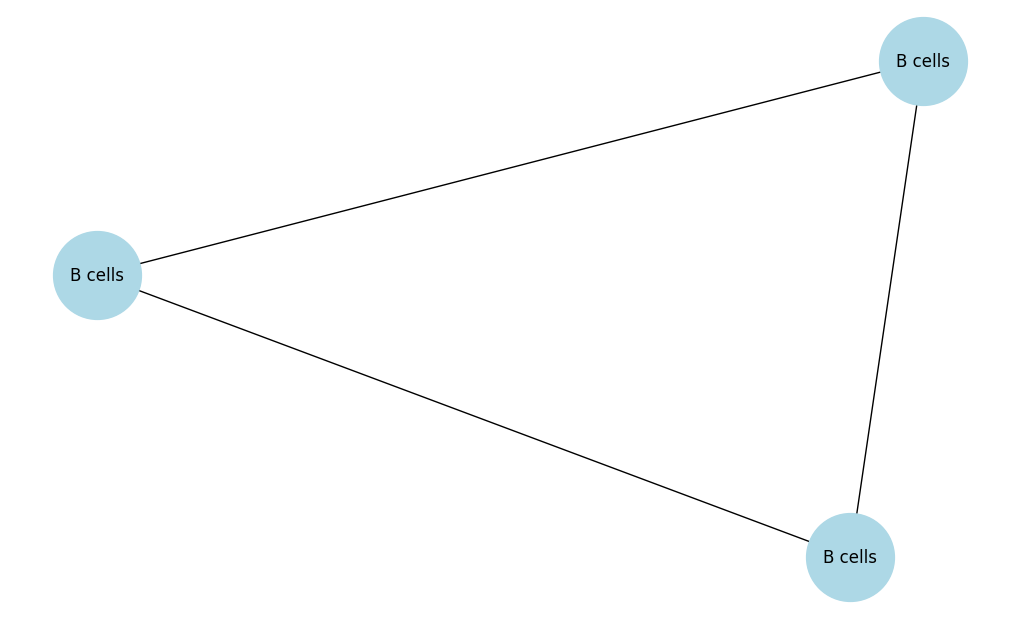

Motif ID: 1332300
Class: Long-term survival
Stringency: 0.3000
Total count: 3697
Score = stringency * count: 1109.1000
A.type = B cells
B.type = CD4 t cells
C.type = CD4 t cells
A -> B
B -> C



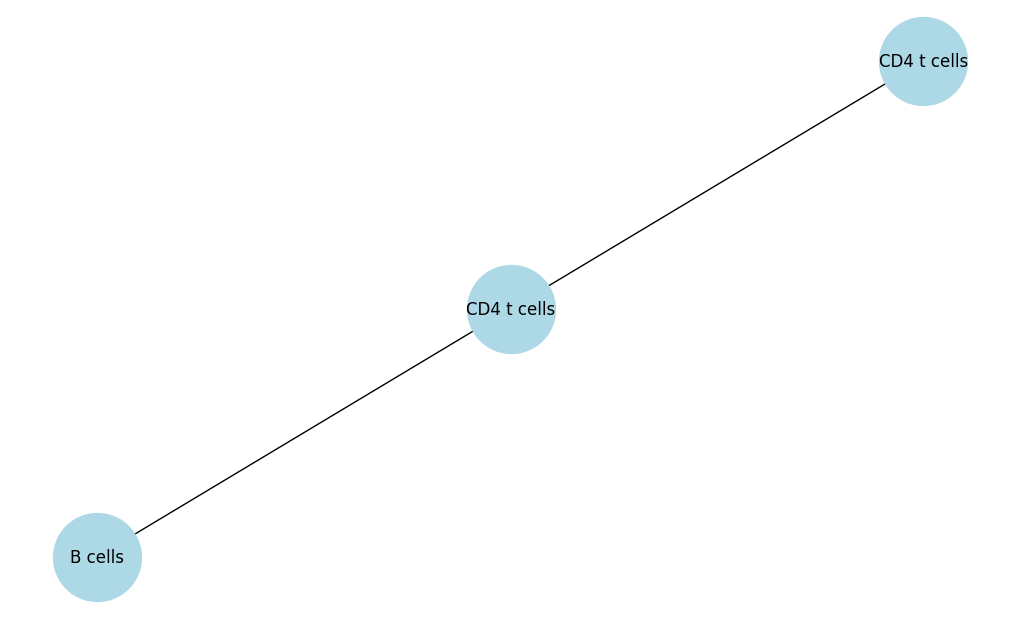

Motif ID: 7722444
Class: Long-term survival
Stringency: 0.1333
Total count: 6305
Score = stringency * count: 840.6667
A.type = CD8 T cells
B.type = Tumor
C.type = Tumor
A -> B
B -> C



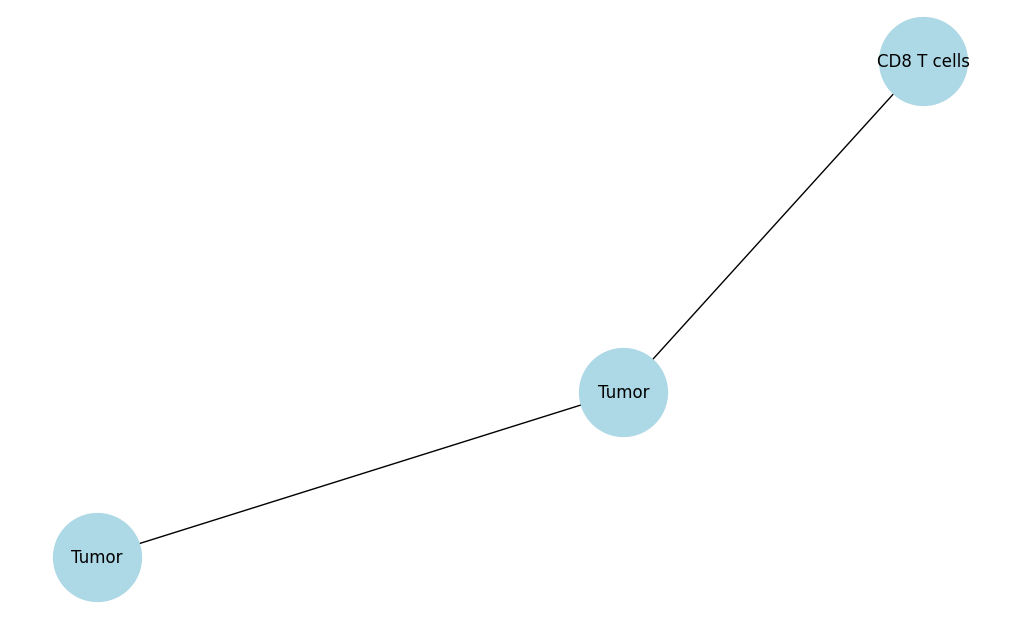

In [9]:
for _, row in top5_motifs_df.iterrows():
    motif_id = int(row["ID"])
    motif_graph = load_motif_graph(row["motif"])

    print(f"Motif ID: {motif_id}")
    print(f"Class: {row['patient_class']}")
    print(f"Stringency: {row['stringency']:.4f}")
    print(f"Total count: {row['total_count']:.0f}")
    print(f"Score = stringency * count: {row['score']:.4f}")
    print(motif_to_annotation_text(motif_graph, common_cells_type))
    draw_motif(motif_graph, common_cells_type)


## Recover The Selected Feature Space

To compare motif-induced pairwise structure to general pairwise structure, we first recover the motif set selected by the chosen analysis configuration.

In [10]:
motif_space_features = discriminator.get_features(
    feature_conf=best_feature_conf,
    exclude_patients=[],
    n_jobs=12,
    prefer="processes",
)

motif_result = GetMotifsResult(
    motif_space_features=motif_space_features,
    discriminator=discriminator,
    classes=labels,
)

motifs_by_class = motif_result.get_motifs_by_class()
motif_mean_weight = motif_result.get_motifs_mean_weight()

print(motifs_by_class)


  0%|          | 0/37 [00:00<?, ?it/s]

{'Short-term survival': [8202636], 'Long-term survival': [3454124, 3964140, 12385516, 1858828, 3955884, 6061228, 11058348, 4750508, 6061356, 6077612, 12369068, 6053036, 6110508, 1866924, 6053164, 12401964, 1850828, 1859020, 6077900, 1867212, 3942476, 18726348, 6052940, 1899980, 3947980, 3470828, 6094060, 5567724, 6052972, 1866860, 3955948, 1858668, 6061292, 3955820, 16574956, 3942636]}


## General Pairwise Analysis Per Disease State

This mirrors the pairwise part of the CRC workflow, but uses the serialized analysis state and the prepared txt graph dataset.

In [11]:
full_graph_df = pd.DataFrame()
full_graph_df = GraphReader.get_graphs(
    full_graph_df=full_graph_df,
    raw_data_folder=network_dataset_root_path,
    raw_data_folder_type=f"/{dataset_folder}",
    disease=artifact.get("dataset_name", dataset_folder),
    cells_type=common_cells_type,
)

pairwise_analysis = PairwiseAnalysis(
    tissue_state_csv_path=tissue_state_csv_path,
    tissue_state_to_string=tissue_state_to_string,
    tissue_state_func=tissue_state_func,
)

display(full_graph_df.head())


,Disease,Patient,file,graph,Columns.PAIRWISE_COUNT,Patient_uId
0,TNBC,10,Patient_10_FOV10.txt,"(0, 62, 77, 1, 36, 43, 78, 108, 2, 3, 48, 6, 8...","[[0.0, 6.0, 4.0, 16.0, 1.0, 8.0, 0.0, 10.0, 24...",TNBC10
1,TNBC,6,Patient_6_FOV6.txt,"(0, 113, 69, 107, 1, 84, 2, 3, 104, 123, 90, 4...","[[24.0, 9.0, 12.0, 6.0, 0.0, 25.0, 3.0, 17.0, ...",TNBC6
2,TNBC,20,Patient_20_FOV20.txt,"(0, 1, 49, 2, 31, 44, 52, 4, 3, 33, 50, 70, 75...","[[4.0, 4.0, 0.0, 14.0, 0.0, 0.0, 0.0, 4.0, 2.0...",TNBC20
3,TNBC,7,Patient_7_FOV7.txt,"(0, 4, 6, 34, 40, 60, 1, 8, 32, 7, 43, 26, 2, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",TNBC7
4,TNBC,40,Patient_40_FOV40.txt,"(0, 1, 24, 36, 52, 27, 3, 2, 59, 28, 48, 35, 4...","[[832.0, 54.0, 204.0, 237.0, 535.0, 65.0, 203....",TNBC40


,B cells,CD3 T cells,CD4 t cells,CD8 T cells,DC,DC/Mono,Endothelial,Immune other,Macrophages,Mesenchyme,Mono/Neu,NK cells,Neutrophils,Tregs,Tumor,Unidentified
B cells,0.001505,0.000019,0.000726,0.000184,0.000018,0.000030,0.000014,0.000067,0.000131,0.000039,0.000013,0.000015,0.000008,0.000003,0.000232,0.000070
CD3 T cells,0.000019,0.000266,0.000689,0.000918,0.000050,0.000129,0.000196,0.000303,0.000592,0.000330,0.000094,0.000057,0.000076,0.000014,0.001285,0.000135
CD4 t cells,0.000726,0.000689,0.019812,0.012063,0.001093,0.001449,0.000224,0.000210,0.003427,0.000114,0.000093,0.001124,0.000418,0.000346,0.002480,0.000027
CD8 T cells,0.000184,0.000918,0.012063,0.023861,0.001447,0.001203,0.000676,0.000535,0.004826,0.000942,0.000427,0.001298,0.000511,0.000278,0.008457,0.000315
DC,0.000018,0.000050,0.001093,0.001447,0.001173,0.000090,0.000068,0.000019,0.000582,0.000073,0.000018,0.000061,0.000060,0.000006,0.001248,0.000000
DC/Mono,0.000030,0.000129,0.001449,0.001203,0.000090,0.000884,0.000066,0.000220,0.000922,0.000228,0.000117,0.000130,0.000066,0.000067,0.001176,0.000035
Endothelial,0.000014,0.000196,0.000224,0.000676,0.000068,0.000066,0.001780,0.000211,0.001661,0.000830,0.000191,0.000098,0.000114,0.000038,0.003759,0.000109
Immune other,0.000067,0.000303,0.000210,0.000535,0.000019,0.000220,0.000211,0.000990,0.001735,0.001331,0.000363,0.000070,0.000253,0.000014,0.004523,0.000596
Macrophages,0.000131,0.000592,0.003427,0.004826,0.000582,0.000922,0.001661,0.001735,0.021774,0.004578,0.001425,0.000439,0.001977,0.000061,0.031533,0.001467
Mesenchyme,0.000039,0.000330,0.000114,0.000942,0.000073,0.000228,0.000830,0.001331,0.004578,0.006996,0.000719,0.000080,0.001005,0.000004,0.014837,0.001829


,B cells,CD3 T cells,CD4 t cells,CD8 T cells,DC,DC/Mono,Endothelial,Immune other,Macrophages,Mesenchyme,Mono/Neu,NK cells,Neutrophils,Tregs,Tumor,Unidentified
B cells,0.018427,0.001101,0.006747,0.002782,0.000876,0.001379,0.000572,0.001584,0.002131,0.001061,0.000135,0.000186,0.000242,0.000196,0.004768,0.000147
CD3 T cells,0.001101,0.001619,0.001879,0.002245,0.000091,0.000835,0.000394,0.001965,0.002269,0.000996,0.000429,0.000026,0.000240,0.000243,0.004071,0.000184
CD4 t cells,0.006747,0.001879,0.012285,0.005768,0.000260,0.002797,0.000568,0.001640,0.005913,0.001424,0.000593,0.000318,0.000598,0.000662,0.007510,0.000162
CD8 T cells,0.002782,0.002245,0.005768,0.015457,0.000249,0.002832,0.000781,0.003571,0.010461,0.002970,0.001260,0.000319,0.001224,0.000844,0.019680,0.000566
DC,0.000876,0.000091,0.000260,0.000249,0.002151,0.000128,0.000524,0.000431,0.000331,0.000740,0.000040,0.000043,0.000047,0.000029,0.000744,0.000027
DC/Mono,0.001379,0.000835,0.002797,0.002832,0.000128,0.003272,0.000365,0.001513,0.003805,0.001431,0.000420,0.000087,0.000232,0.000336,0.004806,0.000185
Endothelial,0.000572,0.000394,0.000568,0.000781,0.000524,0.000365,0.001371,0.001040,0.001428,0.001353,0.000300,0.000037,0.000150,0.000067,0.002515,0.000158
Immune other,0.001584,0.001965,0.001640,0.003571,0.000431,0.001513,0.001040,0.007499,0.006023,0.003079,0.001194,0.000044,0.000647,0.000232,0.007675,0.001192
Macrophages,0.002131,0.002269,0.005913,0.010461,0.000331,0.003805,0.001428,0.006023,0.030267,0.005287,0.003400,0.000355,0.002081,0.001095,0.029904,0.001299
Mesenchyme,0.001061,0.000996,0.001424,0.002970,0.000740,0.001431,0.001353,0.003079,0.005287,0.016684,0.000870,0.000102,0.000452,0.000119,0.017913,0.000895


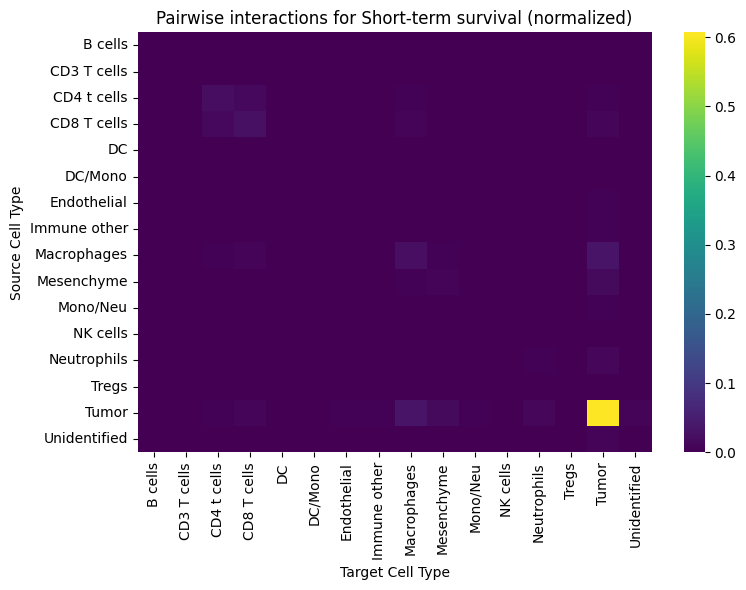

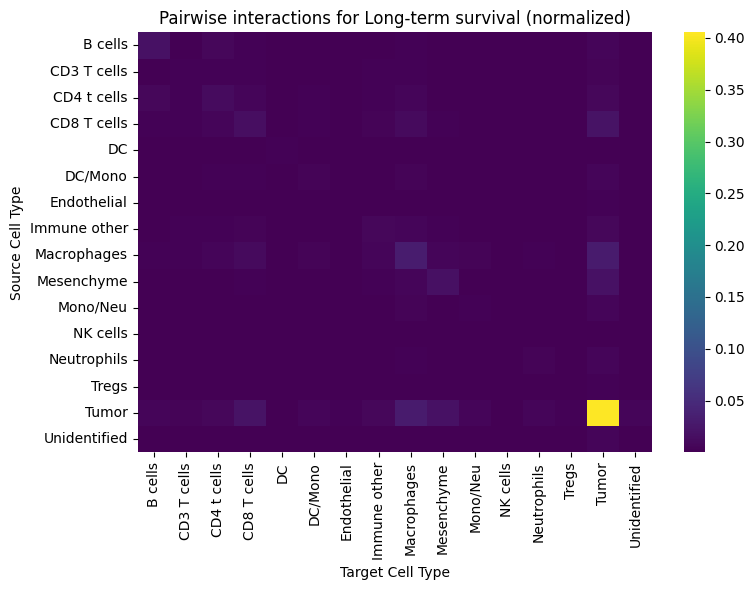

In [12]:
general_pairwise_by_class = {
    patient_class: pairwise_analysis.get_pairwise_counter(
        full_graph_df=full_graph_df,
        patient_class=patient_class,
        cells_type=common_cells_type,
        normalize=True,
    )
    for patient_class in labels
}

for patient_class, matrix in general_pairwise_by_class.items():
    display(matrix)
    pairwise_analysis.plot_pairwise_heatmap(
        full_graph_df=full_graph_df,
        patient_class=patient_class,
        cells_type=common_cells_type,
        normalize=True,
        annotate=False,
    )


## Motif-Induced Pairwise Analysis Per Disease State

Now we derive pairwise cell-type interaction structure induced only by the selected motif set.

motif_id: 8202636, hash_id: -395158436373686009
motif_id: 6052972, hash_id: 6296317540562037293
motif_id: 11058348, hash_id: -3622911041628419534
motif_id: 12369068, hash_id: -3622911041628419534
motif_id: 6077900, hash_id: 6794497112851034106
motif_id: 4750508, hash_id: 6512495239480086935
motif_id: 6061228, hash_id: 6512495239480086935
motif_id: 6061356, hash_id: -5592926003202999446
motif_id: 6077612, hash_id: 391868164882289572
motif_id: 1866860, hash_id: 3580840254939402609
motif_id: 3955948, hash_id: 1953587682041931478
motif_id: 6094060, hash_id: -8232997633730303071
motif_id: 5567724, hash_id: -8232997633730303071
motif_id: 1859020, hash_id: -35336164347311431
motif_id: 1858828, hash_id: -7111421891569733644
motif_id: 1850828, hash_id: -4998257852538314798
motif_id: 3942476, hash_id: 4438386737076452796
motif_id: 3955884, hash_id: 6212072527860847364
motif_id: 1867212, hash_id: 3846638627528876859
motif_id: 6053036, hash_id: -8854845265688850345
motif_id: 6110508, hash_id: 7810

,B cells,CD3 T cells,CD4 t cells,CD8 T cells,DC,DC/Mono,Endothelial,Immune other,Macrophages,Mesenchyme,Mono/Neu,NK cells,Neutrophils,Tregs,Tumor,Unidentified
B cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD3 T cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD4 t cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CD8 T cells,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0
DC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DC/Mono,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Endothelial,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Immune other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophages,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mesenchyme,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


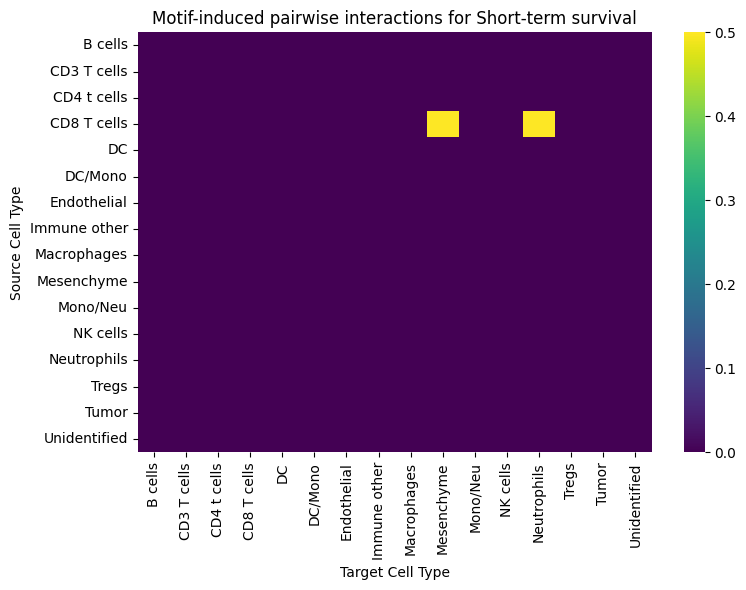

,B cells,CD3 T cells,CD4 t cells,CD8 T cells,DC,DC/Mono,Endothelial,Immune other,Macrophages,Mesenchyme,Mono/Neu,NK cells,Neutrophils,Tregs,Tumor,Unidentified
B cells,0.0,0.006920,0.058304,0.059895,0.0,0.006523,0.0,0.007350,0.013338,0.000000,0.0,0.0,0.0,0.000000,0.050301,0.000000
CD3 T cells,0.0,0.024368,0.026819,0.014386,0.0,0.011650,0.0,0.025399,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.015438,0.000000
CD4 t cells,0.0,0.000000,0.113191,0.097146,0.0,0.074931,0.0,0.032218,0.013338,0.025376,0.0,0.0,0.0,0.000000,0.031750,0.000000
CD8 T cells,0.0,0.000000,0.000000,0.009157,0.0,0.031485,0.0,0.013210,0.000000,0.005694,0.0,0.0,0.0,0.000000,0.013061,0.000000
DC,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
DC/Mono,0.0,0.000000,0.000000,0.000000,0.0,0.086712,0.0,0.009638,0.000000,0.012108,0.0,0.0,0.0,0.000000,0.008780,0.000000
Endothelial,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
Immune other,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.042548,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.007350,0.025318
Macrophages,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.004566,0.004566,0.000000
Mesenchyme,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.012602,0.0,0.0,0.0,0.000000,0.000000,0.000000


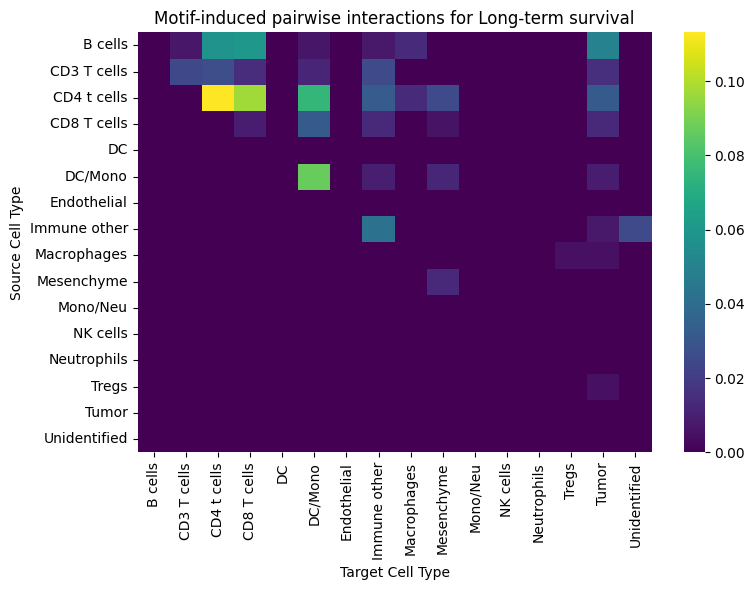

In [13]:
motif_induced_pairwise_by_class = {
    patient_class: create_weight_matrix_from_motifs(
        discriminator=discriminator,
        cells_type=common_cells_type,
        cell_identity_to_motif_hash=motif_result.cell_identity_to_motif_hash,
        motifs_ids=motifs_by_class[patient_class],
        motifs_weight=motif_mean_weight,
    )
    for patient_class in labels
}

for patient_class, matrix in motif_induced_pairwise_by_class.items():
    display(matrix)
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, cmap="viridis")
    plt.title(f"Motif-induced pairwise interactions for {patient_class}")
    plt.xlabel("Target Cell Type")
    plt.ylabel("Source Cell Type")
    plt.tight_layout()
    plt.show()


## Compare Motif-Induced Vs General Pairwise Structure

For each disease state, we compare the global pairwise background to the pairwise structure induced by the selected motifs.

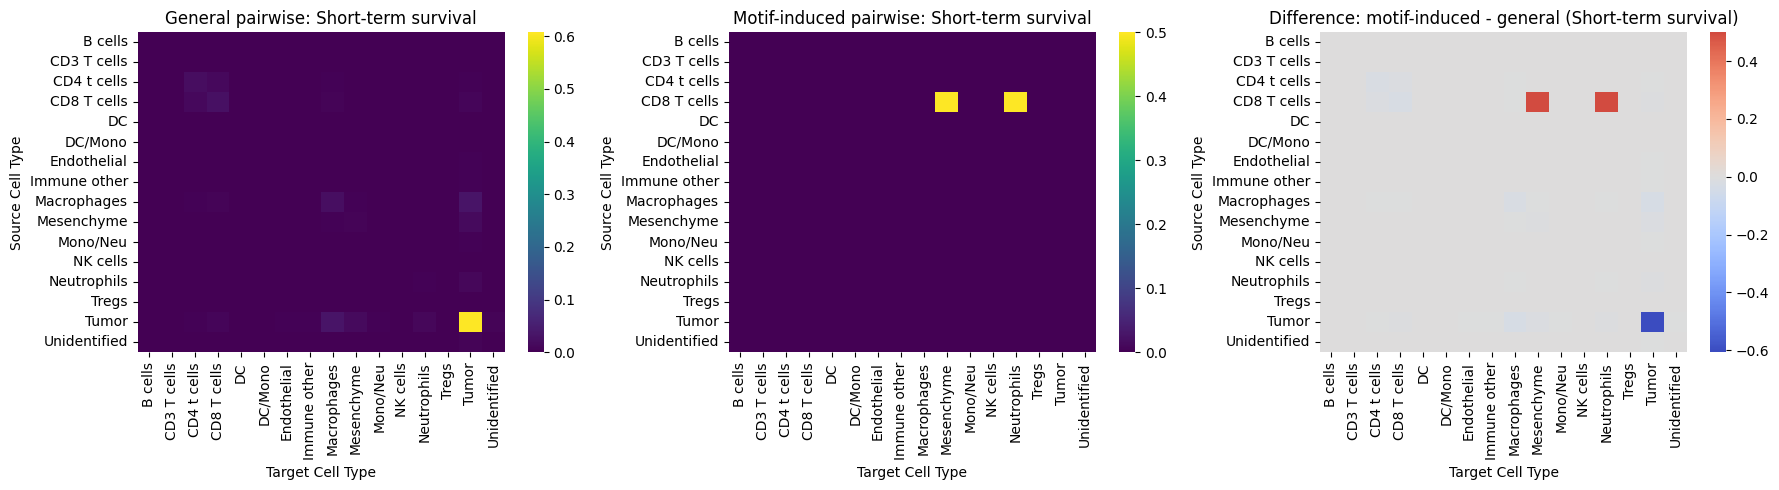

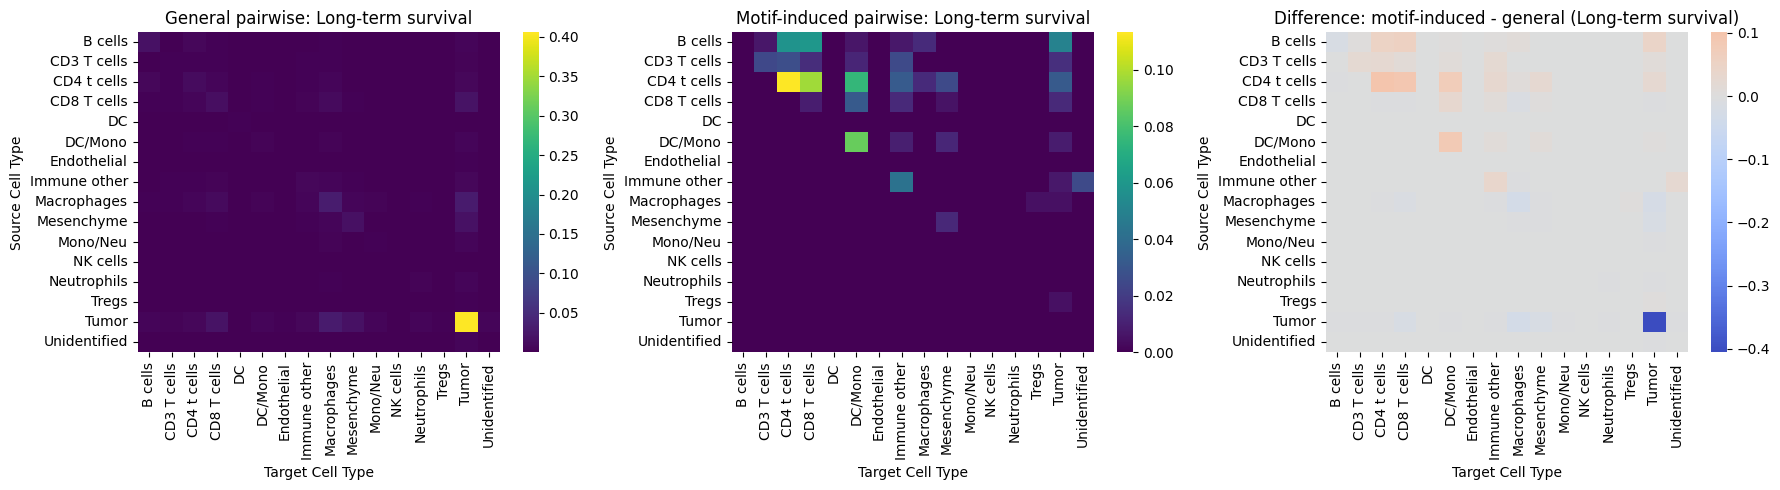

In [14]:
pairwise_comparison = {}
for patient_class in labels:
    general_matrix = general_pairwise_by_class[patient_class]
    motif_matrix = motif_induced_pairwise_by_class[patient_class]
    difference_matrix = motif_matrix - general_matrix
    pairwise_comparison[patient_class] = {
        "general": general_matrix,
        "motif_induced": motif_matrix,
        "difference": difference_matrix,
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(general_matrix, cmap="viridis", ax=axes[0])
    axes[0].set_title(f"General pairwise: {patient_class}")

    sns.heatmap(motif_matrix, cmap="viridis", ax=axes[1])
    axes[1].set_title(f"Motif-induced pairwise: {patient_class}")

    sns.heatmap(difference_matrix, cmap="coolwarm", center=0, ax=axes[2])
    axes[2].set_title(f"Difference: motif-induced - general ({patient_class})")

    for ax in axes:
        ax.set_xlabel("Target Cell Type")
        ax.set_ylabel("Source Cell Type")

    plt.tight_layout()
    plt.show()


## Export Visualization Inputs For The Top 5 Motifs

This step creates, for each of the top 5 motifs:

- `<motif_id>.txt`
- `<motif_id>_hits_wide.csv`

These match the annotation/hit-table format you showed and can be reused for motif visualization and later post-processing.

### Dataset-Specific Input Needed Here

The hit-finder works on the original cell-level CSV, so set that path and the relevant column names below.

Replace the defaults with the actual file and schema for your dataset.

In [15]:
# Replace with your original cell-level CSV.
raw_cells_csv_path = "mapped_cell_types.csv"

# Replace these column names as needed for your dataset.
fov_col = "fov"
id_col = "cell_id"
x_col = "centroid-0"
y_col = "centroid-1"
type_col = "pred_mapped"
class_col = "Group"
patient_col = "patient number"

# Usually keep this aligned with the classes stored in the artifact.
export_classes = labels


In [16]:
top_motif_export_df = export_top_motif_visualization_inputs(
    discriminator=discriminator,
    discover_result=discover_result,
    raw_cells_csv_path=raw_cells_csv_path,
    output_dir=str(TOP_MOTIF_EXPORT_ROOT),
    top_k=5,
    fov_col=fov_col,
    id_col=id_col,
    x_col=x_col,
    y_col=y_col,
    type_col=type_col,
    class_col=class_col,
    classes=export_classes,
    patient_col=patient_col,
    induced=False,
)

display(top_motif_export_df)


FileNotFoundError: [Errno 2] No such file or directory: 'mapped_cell_types.csv'

## Output Summary

This notebook leaves you with:

- analysis plots
- pairwise comparison matrices
- the top 5 motifs drawn from the selected discriminative state
- annotation text files and exact-hit CSV files for those motifs

In [ ]:
print("Notebook 03 summary:")
print(f"artifact_path = {artifact_path}")
print(f"dataset_dir = {dataset_dir}")
print(f"top motif export directory = {TOP_MOTIF_EXPORT_ROOT}")
print(f"top 5 motif ids = {top5_motifs_df['ID'].tolist()}")
print(f"best shared_percentage = {best_feature_conf.shared_percentage}")
print(f"best max_class_features = {best_feature_conf.max_class_features}")


Notebook 03 summary:
artifact_path = /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/serialized/TNBC_cism_ready.pkl
dataset_dir = /home/omriavit/CISM/CISM_paper_revision/pet_data/TNBC
top motif export directory = /home/omriavit/CISM/CISM_paper_revision/tutorials/runtime/analysis_outputs/motif_visualization_inputs
top 5 motif ids = [531468, 1837132, 1842188, 1332300, 7722444]
best shared_percentage = 0.35305017074373957
best max_class_features = 30


## Ready For The Next Step

At this point, we can continue into deeper post-processing and visualization using:

- the saved CISM/discriminator artifact
- the pairwise comparison outputs
- the top-motif annotation files
- the top-motif hit tables

This is the right point to branch into the additional analysis ideas you want to add next.